## Minimal example of calculating NPQ-corrected fluorescence from float data

This notebook calculates alpha_NPQ for a number of floats measuring the necessary parameters

### Import packages, define function, read in float data

In [1]:
import xarray as xr
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import argopy
from argopy import ArgoFloat

In [2]:
from scripts.npqc import calculate_NPQ_fluo
from scripts.par15 import par15
from scripts.mld_calculator import mld_calc
from scripts.fit_npq import fit_alpha_npq

### Read CSV of float IDs
Only read 30 random ones at a time so it doesn't get overloaded

In [4]:
df = pd.read_csv('data/iron_stress_floats.csv')

In [48]:
WMOa = df['floats'].to_numpy()
ix = np.random.randint(len(WMOa), size=(30, ))
WMOs = WMOa[ix]

In [49]:
WMOs

array([6903805, 6902968, 6903553, 2902936, 6903069, 6901860, 2902823,
       5906971, 4902688, 6903578, 3901530, 1902751, 6902901, 7901028,
       4902688, 6901687, 6903130, 6902738, 6904116, 6990700, 6903026,
       5905023, 6901774, 2902913, 6904235, 3902121, 5906990, 6902701,
       6904183, 6903576])

In [50]:
#dsa = dict()
for ii in range(len(WMOs)):
    with argopy.set_options(mode='expert'):
        ds = ArgoFloat(str(WMOs[ii])).open_dataset('Sprof')
    if not 'CHLA_FLUORESCENCE_ADJUSTED' in list(ds.variables):
        continue
    ds = par15(ds).rename({'par_15_pressure': 'par_depth'})
    ds = mld_calc(ds)
    ds = ds.dropna(dim='N_PROF', subset=['par_depth', 'ml_depth'])
    try:
        ds = calculate_NPQ_fluo(ds)
        ds = fit_alpha_npq(ds)
        ds['alpha_NPQ_QC'] = ds['alpha_NPQ'].where(
            (ds['NPQ_max'] < 20) & (ds['alpha_NPQ'] < 0.0999), np.nan)
        dsa[str(WMOs[ii])] = ds
    except:
        print('Didnt work')

/opt/conda/lib/python3.13/site-packages/xarray/computation/fit.py:484: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, pcov = curve_fit(func, x, y, p0=p0_, bounds=(lb, ub), **kwargs)


Didnt work


/opt/conda/lib/python3.13/site-packages/xarray/computation/fit.py:484: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, pcov = curve_fit(func, x, y, p0=p0_, bounds=(lb, ub), **kwargs)


Didnt work


Didnt work


...

Didnt work


/opt/conda/lib/python3.13/site-packages/numpy/_core/fromnumeric.py:3862: RuntimeWarning: Mean of empty slice
  return _methods._mean(a, axis=axis, dtype=dtype,
/opt/conda/lib/python3.13/site-packages/numpy/_core/_methods.py:142: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/opt/conda/lib/python3.13/site-packages/numpy/_core/fromnumeric.py:3862: RuntimeWarning: Mean of empty slice
  return _methods._mean(a, axis=axis, dtype=dtype,
/opt/conda/lib/python3.13/site-packages/numpy/_core/_methods.py:142: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/opt/conda/lib/python3.13/site-packages/numpy/_core/fromnumeric.py:3862: RuntimeWarning: Mean of empty slice
  return _methods._mean(a, axis=axis, dtype=dtype,
/opt/conda/lib/python3.13/site-packages/numpy/_core/_methods.py:142: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


/opt/conda/lib/python3.13/site-packages/xarray/computation/fit.py:484: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, pcov = curve_fit(func, x, y, p0=p0_, bounds=(lb, ub), **kwargs)


/opt/conda/lib/python3.13/site-packages/xarray/computation/fit.py:484: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, pcov = curve_fit(func, x, y, p0=p0_, bounds=(lb, ub), **kwargs)


/opt/conda/lib/python3.13/site-packages/xarray/computation/fit.py:484: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, pcov = curve_fit(func, x, y, p0=p0_, bounds=(lb, ub), **kwargs)


In [51]:
dsa.keys()

dict_keys(['6901494', '6901861', '6901774', '6901581', '3901582', '5906765', '7902195', '6902735', '6901151', '6901032', '6901181', '6901863', '5907055', '6901524', '6902896', '4901806', '7900583', '6990636', '6901864', '6902829', '6901576', '6903825', '6901483', '6903805', '6903553', '5906971', '6903578', '3901530', '1902751', '6902901', '7901028', '6901687', '6902738', '6904116', '6990700', '6903026', '3902121', '6902701', '6904183', '6903576'])

In [79]:
WMOs[ii]

np.int64(1902651)

### Calculate NPQ
Eq. 2 from [Schallenberg et al. 2022](https://doi.org/10.1029/2021GL097616)

In [8]:
ds['NPQ'] = (ds['fluo_npqc']-ds['fluo_smooth'])/ds['fluo_smooth']

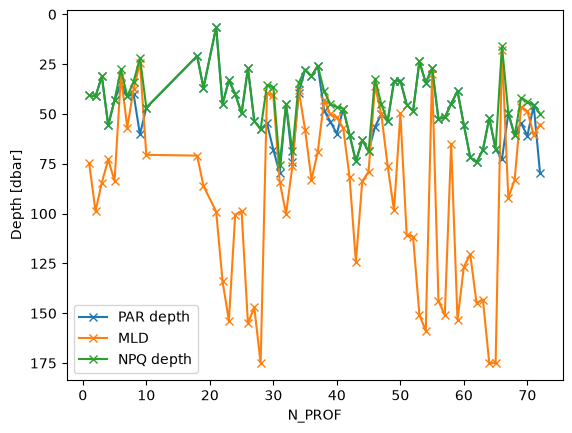

In [9]:
fig, ax = plt.subplots()
ds['par_depth'].plot.line('-x', label='PAR depth')
ds['ml_depth'].plot.line('-x', label='MLD')
ds['NPQ_depth'].plot.line('-x', label='NPQ depth')
ax.set_ylabel('Depth [dbar]')
plt.legend()
ax.set_ylim(ax.get_ylim()[::-1]);

<xarray.DataArray 'alpha_NPQ_QC' (N_PROF: 59)> Size: 472B
array([0.00381698, 0.00381698, 0.00707502, 0.00530626, 0.0061463 ,
       0.00503837, 0.00461913, 0.00214292, 0.00300166, 0.00623635,
       0.00610485, 0.0138291 , 0.01500027, 0.01616118, 0.01354961,
       0.01367442, 0.00641168, 0.00561882, 0.00575911, 0.00610621,
       0.01007039, 0.01094629, 0.01192104, 0.01283253, 0.01239637,
       0.00976921, 0.00895926, 0.00735497, 0.00525637, 0.00490737,
       0.00519125, 0.00585566, 0.00814741, 0.0081056 , 0.007987  ,
       0.00675363, 0.00565658, 0.00328102, 0.0042815 , 0.00470055,
       0.00730032, 0.00714281, 0.00720238, 0.00629721, 0.00632243,
       0.00341969, 0.00313375, 0.00327062, 0.00270231, 0.00286628,
       0.0043199 , 0.00423507, 0.00388143, 0.00449395, 0.00386687,
       0.00240898, 0.00316737, 0.00413852, 0.00413852])
Coordinates:
  * N_PROF   (N_PROF) int64 472B 1 3 4 5 6 7 8 9 10 ... 53 54 55 56 57 58 59 60
    param    <U9 36B 'NPQ_max'

In [42]:
dsb

<xarray.Dataset> Size: 36MB
Dimensions:                            (N_PROF: 59, N_PARAM: 13, N_CALIB: 1,
                                        N_LEVELS: 1322)
Coordinates:
  * N_PROF                             (N_PROF) int64 472B 1 3 4 5 ... 58 59 60
    param                              <U9 36B 'NPQ_max'
Dimensions without coordinates: N_PARAM, N_CALIB, N_LEVELS
Data variables: (12/131)
    DATA_TYPE                          <U32 128B ...
    FORMAT_VERSION                     <U4 16B ...
    HANDBOOK_VERSION                   <U4 16B ...
    REFERENCE_DATE_TIME                datetime64[ns] 8B ...
    DATE_CREATION                      datetime64[ns] 8B ...
    DATE_UPDATE                        datetime64[ns] 8B ...
    ...                                 ...
    fluo_npqc                          (N_PROF, N_LEVELS) float32 312kB 0.036...
    npq                                (N_PROF, N_LEVELS) float32 312kB -0.03...
    par                                (N_PROF, N_LEVELS) float32 312kB nan ....
    NPQ_max                            (N_PROF) float64 472B 0.1613 ... 1.009
    alpha_NPQ                          (N_PROF) float64 472B 0.1 ... 0.003469
    alpha_NPQ_QC                       (N_PROF) float64 472B nan ... 0.003469
Attributes:
    title:                Argo float vertical profile
    institution:          CORIOLIS
    source:               Argo float
    history:              2026-06-26T19:17:09Z creation (software version 1.2...
    references:           http://www.argodatamgt.org/Documentation
    user_manual_version:  1.0
    Conventions:          Argo-3.1 CF-1.6
    featureType:          trajectoryProfile
    software_version:     1.22 (version 12.05.2025 for ARGO_simplified_profile)
    id:                   https://doi.org/10.17882/42182

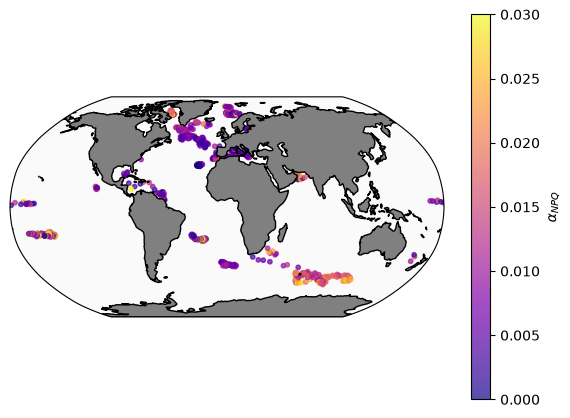

In [67]:

import cartopy.crs as ccrs
import cartopy.feature as cfeature
#map_proj =ccrs.InterruptedGoodeHomolosine(central_longitude=0, globe=None, emphasis='ocean')

fig = plt.figure(figsize=(7,5))
fig.patch.set_alpha(0)
ax0 = fig.add_subplot(1,1,1, projection=ccrs.Robinson())
ax0.set_global()
ax0.add_feature(cfeature.NaturalEarthFeature('physical', 'land', '110m', edgecolor='k', facecolor=[.5, .5 ,.5]))
ax0.set_facecolor('.98')

for key in list(dsa.keys()):
    dsb = dsa[key]
    dsb['clr'] = dsb['alpha_NPQ_QC'].rolling(N_PROF=5, center=True, min_periods=1).mean()
    dsb = dsb.isel(N_PROF=range(2, dsb['N_PROF'].shape[0], 5))
    plt.scatter(dsb['LONGITUDE'], dsb['LATITUDE'], transform=ccrs.PlateCarree(),
            s = 10, c=dsb['clr'].to_numpy(), vmin=0, vmax=.03, alpha=.7, 
                cmap='plasma')
plt.colorbar(label='$\\alpha_{NPQ}$')
#plt.savefig('../global_anpq_v2b.png')#, transparent=True)

(182.90699291229248, 9.833001136779785)

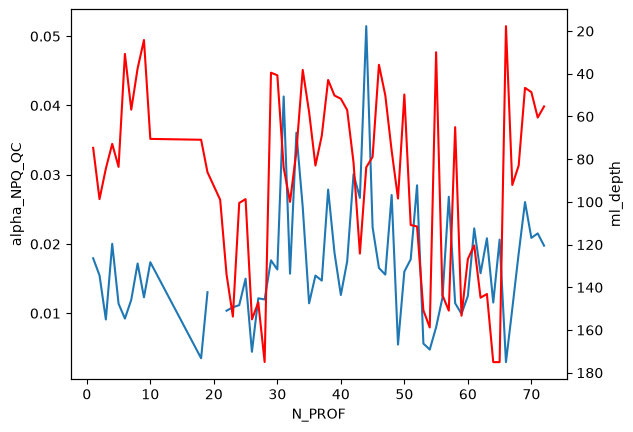

In [13]:
fig2, ax2 = plt.subplots()
ds['alpha_NPQ_QC'].plot()
ax2b = ax2.twinx()
ds['ml_depth'].plot(ax=ax2b, color='r')
ax2b.set_ylim(ax2b.get_ylim()[::-1])

#sc.stats.pearsonr(ds['alpha_NPQ'], ds['ml_depth'])

In [ ]:
fig, ax = plt.subplots()
plt.plot(ds['fluo_smooth'].T, ds['PRES_ADJUSTED'].T, '-')
plt.plot(ds['fluo_npqc'].T, ds['PRES_ADJUSTED'].T, '--')
# match line colors
h1 = ax.get_children()
for hh in range(13, 24):
    h1[hh].set_color(h1[hh-12].get_color())
ax.set_ylim([250, 0])